# Kuramoto order-parameter benchmark

A frozen Pearson SPI–SPI PC1 is fit without order-parameter or control labels on Gaussian development masters. It is evaluated on held-out Gaussian masters and a logistic-frequency path. The target is future full-system phase coherence, while SPI–SPI sees only the preceding $20\times1000$ cosine observation. PC1 sign is arbitrary; absolute association is used where direction is immaterial. Isotonic calibration is supervised and reported separately.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.order_parameter_analysis import clustered_bootstrap_mae, clustered_bootstrap_spearman

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'src').exists():
    ROOT = ROOT.parent
DATA = ROOT / 'data/order_parameter/kuramoto_order_benchmark'
with np.load(DATA / 'benchmark_results.npz') as archive:
    results = {name: archive[name] for name in archive.files}
summary = json.loads((DATA / 'benchmark_summary.json').read_text())
frame = pd.DataFrame({
    'distribution': results['distribution'], 'design': results['design'],
    'split': results['split'], 'instance': results['instance'], 'kappa': results['kappa'],
    'R': results['r_full_future'],
    'q': results['coordinate_spi_spi_pc1'],
    'q_no_phase': results['coordinate_spi_spi_pc1_no_phase'],
    'R_hat_spi': results['prediction_spi_spi_pc1'],
    'R_hat_kappa': results['prediction_control_kappa'],
})
paired = frame[frame.design == 'paired'].copy()
evaluation = paired[paired.split == 'evaluation'].copy()

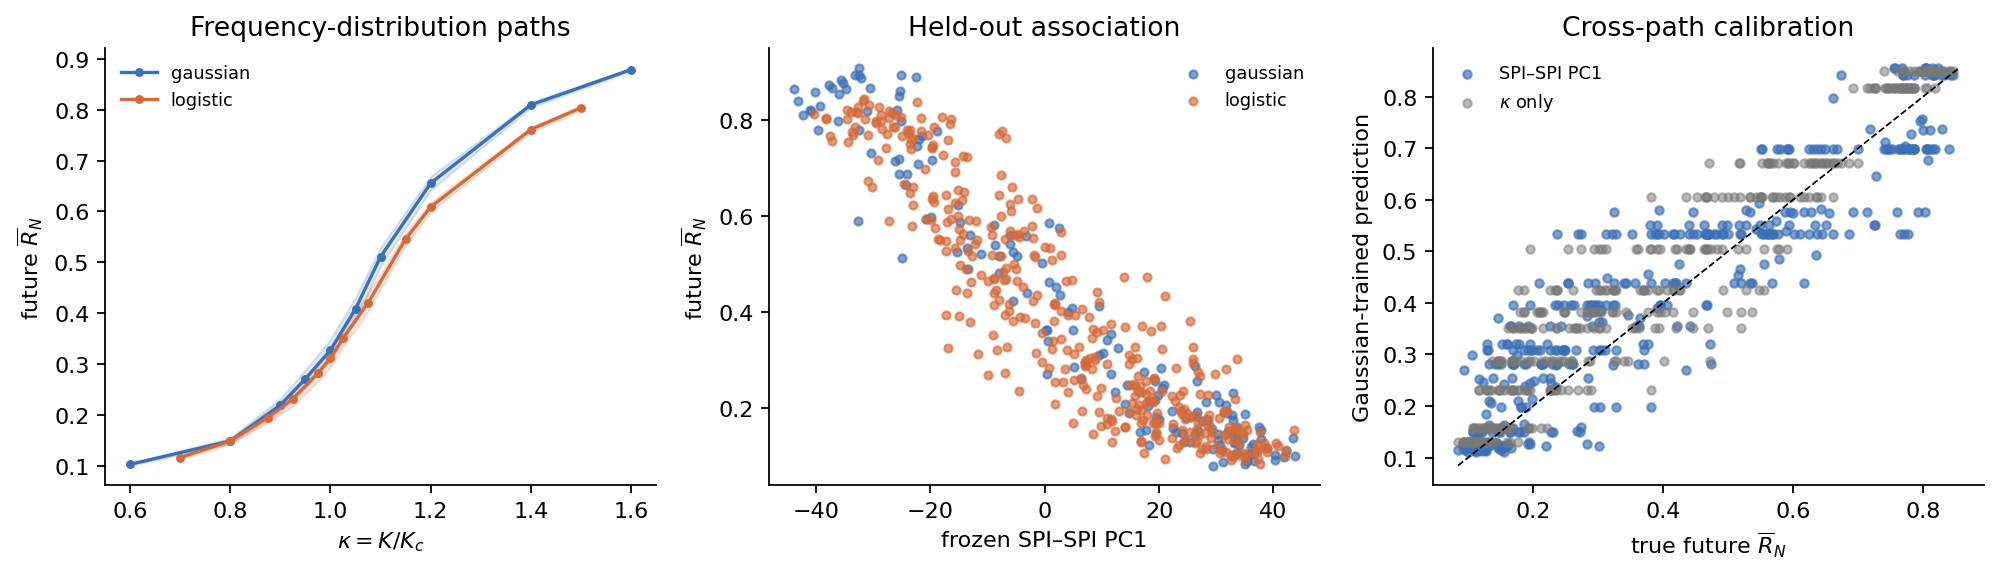

In [2]:
colors = {'gaussian': '#3B6FB6', 'logistic': '#D46A3A'}
fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.7), dpi=160)
for distribution, group in paired.groupby('distribution'):
    curve = group.groupby('kappa').R.agg(['mean', 'sem']).reset_index()
    axes[0].plot(curve.kappa, curve['mean'], '-o', ms=3, color=colors[distribution], label=distribution)
    axes[0].fill_between(curve.kappa, curve['mean']-curve['sem'], curve['mean']+curve['sem'], color=colors[distribution], alpha=.16)
    subset = evaluation[evaluation.distribution == distribution]
    axes[1].scatter(subset.q, subset.R, s=13, alpha=.65, color=colors[distribution], label=distribution)
logistic = evaluation[evaluation.distribution == 'logistic']
axes[2].scatter(logistic.R, logistic.R_hat_spi, s=14, alpha=.65, label='SPI–SPI PC1', color='#3B6FB6')
axes[2].scatter(logistic.R, logistic.R_hat_kappa, s=14, alpha=.5, label=r'$\kappa$ only', color='#777777')
limits = [float(logistic[['R','R_hat_spi','R_hat_kappa']].min().min()), float(logistic[['R','R_hat_spi','R_hat_kappa']].max().max())]
axes[2].plot(limits, limits, 'k--', lw=.8)
axes[0].set(xlabel=r'$\kappa=K/K_c$', ylabel=r'future $\overline{R}_N$', title='Frequency-distribution paths')
axes[1].set(xlabel='frozen SPI–SPI PC1', ylabel=r'future $\overline{R}_N$', title='Held-out association')
axes[2].set(xlabel=r'true future $\overline{R}_N$', ylabel=r'Gaussian-trained prediction', title='Cross-path calibration')
for ax in axes:
    ax.spines[['top','right']].set_visible(False); ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

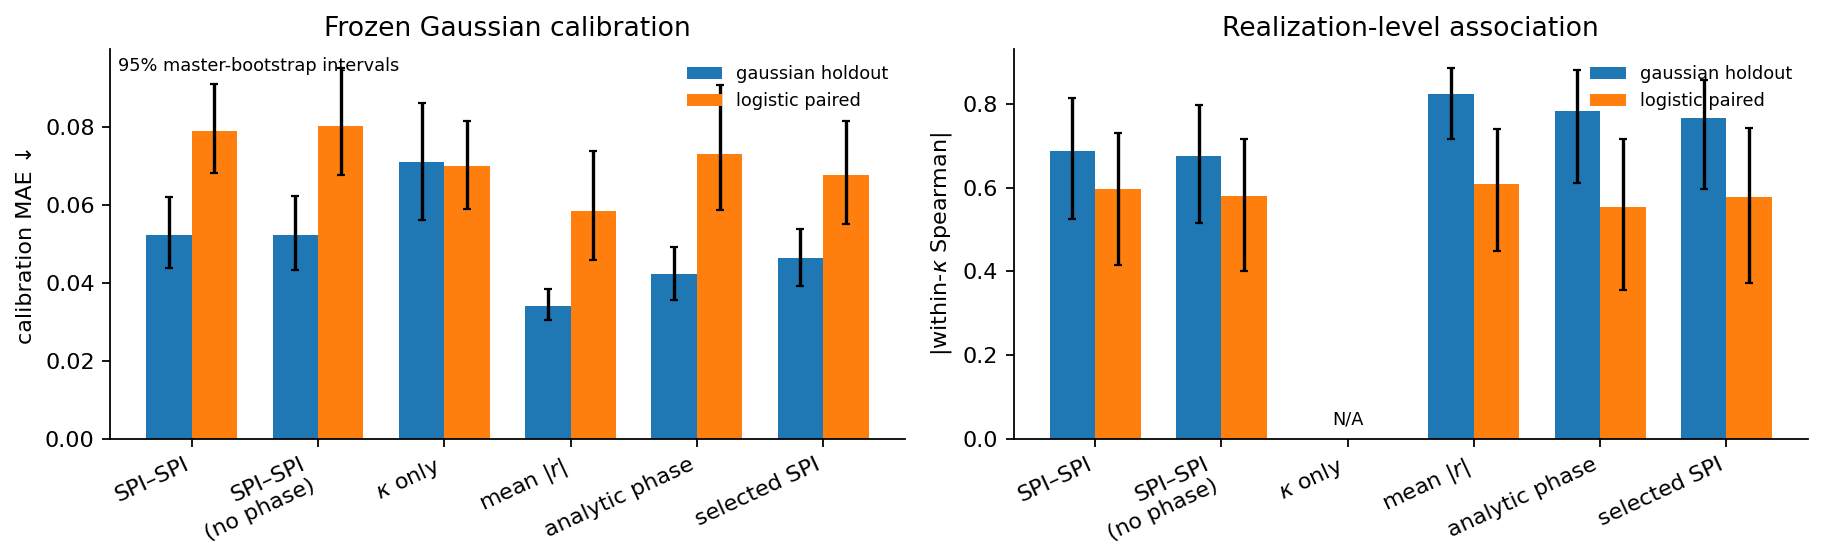

In [3]:
methods = ['spi_spi_pc1', 'spi_spi_pc1_no_phase', 'control_kappa', 'mean_abs_correlation', 'analytic_phase_coherence', 'train_selected_individual_spi_summary']
labels = ['SPI–SPI', 'SPI–SPI\n(no phase)', r'$\kappa$ only', r'mean $|r|$', 'analytic phase', 'selected SPI']
sets = ['gaussian_holdout', 'logistic_paired']
set_masks = {
    'gaussian_holdout': (results['distribution'] == 'gaussian') & (results['design'] == 'paired') & (results['split'] == 'evaluation'),
    'logistic_paired': (results['distribution'] == 'logistic') & (results['design'] == 'paired') & (results['split'] == 'evaluation'),
}

def master_intervals(set_name, method, seed):
    mask = set_masks[set_name]
    truth, groups, clusters = results['r_full_future'][mask], results['kappa'][mask], results['instance'][mask]
    mae_draws = clustered_bootstrap_mae(truth, results[f'prediction_{method}'][mask], clusters, n_resamples=1000, seed=seed)
    if method == 'control_kappa':
        within_interval = np.array([np.nan, np.nan])
    else:
        _, within_draws = clustered_bootstrap_spearman(results[f'coordinate_{method}'][mask], truth, groups, clusters, n_resamples=1000, seed=seed)
        within_interval = np.quantile(np.abs(within_draws), [.025, .975])
    return np.quantile(mae_draws, [.025, .975]), within_interval

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6), dpi=160)
x = np.arange(len(methods)); width = .36
for offset, set_name in enumerate(sets):
    intervals = [master_intervals(set_name, method, 100 + 10*offset + index) for index, method in enumerate(methods)]
    values = np.array([summary['metrics'][set_name][method]['mae'] for method in methods])
    bounds = np.array([interval[0] for interval in intervals]).T
    axes[0].bar(x + (offset-.5)*width, values, width, yerr=np.vstack([values-bounds[0], bounds[1]-values]), capsize=2, label=set_name.replace('_',' '))
    values = np.array([abs(summary['metrics'][set_name][method]['within_kappa_spearman']) if summary['metrics'][set_name][method]['within_kappa_spearman'] is not None else np.nan for method in methods])
    bounds = np.array([interval[1] for interval in intervals]).T
    axes[1].bar(x + (offset-.5)*width, values, width, yerr=np.vstack([values-bounds[0], bounds[1]-values]), capsize=2, label=set_name.replace('_',' '))
axes[0].set(ylabel='calibration MAE ↓', title='Frozen Gaussian calibration')
axes[1].set(ylabel=r'$|$within-$\kappa$ Spearman$|$', title='Realization-level association')
axes[0].text(.01, .98, '95% master-bootstrap intervals', transform=axes[0].transAxes, va='top', fontsize=8)
axes[1].text(x[2], .025, 'N/A', ha='center', va='bottom', fontsize=8)
for ax in axes:
    ax.set_xticks(x, labels, rotation=25, ha='right'); ax.spines[['top','right']].set_visible(False); ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

In [4]:
decision = summary['claim_decision']
level = decision['maximum_supported_level']
claims = {
    0: 'The frozen primary claim is ineligible; secondary associations remain descriptive.',
    1: 'SPI–SPI learns an unsupervised coordinate associated with the synchronization transition.',
    2: 'SPI–SPI tracks realization-level variation in an independently defined macroscopic order parameter.',
    3: 'SPI–SPI supports data-driven discovery of an order-parameter coordinate from partial observations across distinct microscopic synchronization paths.',
}
print(f'Frozen claim level: {level}/3')
print(claims[level])
gate = summary['missingness_gates']['spi_spi_pc1']
n_missing = int((results['spi_spi_missing_fraction'][frame.split == 'evaluation'] > 0).sum())
print(f"Missing meta-features occurred in {n_missing}/720 evaluation rows (p95={gate['observed_p95']:.3f}, max={gate['observed_max']:.3f}); the predeclared maximum gate was {gate['max_allowed']:.2f}.")
pd.DataFrame({
    'criterion': ['level 1', 'level 2', 'level 3', 'logistic SPI–SPI minus kappa MAE CI'],
    'result': [decision['level_1_transition_coordinate'], decision['level_2_realization_level_order_coordinate'], decision['level_3_cross_path_order_parameter_inference'], decision['logistic_spi_spi_minus_kappa_mae_ci95']],
})

Frozen claim level: 0/3
The frozen primary claim is ineligible; secondary associations remain descriptive.
Missing meta-features occurred in 4/720 evaluation rows (p95=0.000, max=0.118); the predeclared maximum gate was 0.05.


,criterion,result
0,level 1,False
1,level 2,False
2,level 3,False
3,logistic SPI–SPI minus kappa MAE CI,"[-0.008924704105159635, 0.02659489714045945]"
